# BIG vs SMALL snowfall comparison
This notebook loads **both** cases (`big` and `small`) and produces plots as **left/right subfigures**:
- **Left = BIG snowfall**
- **Right = SMALL snowfall**

It also includes the **lowest layers** diagnostics and the **common active layers** analyses (HS and SWE), also split left/right.

Assumptions:
- You are running this notebook from `.../R_comparisson/output` (or you update `OUT_ROOT`).
- The NetCDF paths match your folder structure.


In [2]:
# Imports
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import matplotlib.pyplot as plt


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import matplotlib.dates as mdates

## 0) Paths and case configuration (loads both cases)

In [3]:
PROJECT_ROOT = Path.cwd()

CASE_PATHS = {
    "big": {
        "dsnow_nc":  Path("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/big_snowfall/_dsnow_layers_synthetic_big_snowfall_100days.nc"),
        "hs2swe_nc": Path("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/big_snowfall/_hs2swe_layers_synthetic_big_snowfall_100days.nc"),
    },
    "small": {
        "dsnow_nc":  PROJECT_ROOT / "output" / "small_snowfall" / "_dsnow_layers_synthetic_small_snowfall_100days.nc",
        "hs2swe_nc": PROJECT_ROOT / "output" / "small_snowfall" / "_hs2swe_layers_synthetic_small_snowfall_100days.nc",
    },
}

for k in ["big", "small"]:
    print(f"\n{k.upper()} case paths:")
    print("  DSNOW :", CASE_PATHS[k]["dsnow_nc"])
    print("  HS2SWE:", CASE_PATHS[k]["hs2swe_nc"])

    if not CASE_PATHS[k]["dsnow_nc"].exists():
        raise FileNotFoundError(CASE_PATHS[k]["dsnow_nc"])
    if not CASE_PATHS[k]["hs2swe_nc"].exists():
        raise FileNotFoundError(CASE_PATHS[k]["hs2swe_nc"])

print("\nAll required files found.")


BIG case paths:
  DSNOW : /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/big_snowfall/_dsnow_layers_synthetic_big_snowfall_100days.nc
  HS2SWE: /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/big_snowfall/_hs2swe_layers_synthetic_big_snowfall_100days.nc

SMALL case paths:
  DSNOW : /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/small_snowfall/_dsnow_layers_synthetic_small_snowfall_100days.nc
  HS2SWE: /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/small_snowfall/_hs2swe_layers_synthetic_small_snowfall_100days.nc

All required files found.


# Helper functions

In [4]:
def as_time_layer(da: xr.DataArray) -> np.ndarray:
    if tuple(da.dims) == ("time", "layer"):
        return da.values
    if tuple(da.dims) == ("layer", "time"):
        return np.swapaxes(da.values, 0, 1)
    raise ValueError(f"Unexpected dims for {da.name}: {da.dims}")

def flatten_nonzero(da: xr.DataArray) -> np.ndarray:
    a = as_time_layer(da).ravel()
    a = a[np.isfinite(a)]
    a = a[a != 0]
    return a

def stats_table(values: np.ndarray) -> pd.Series:
    v = np.asarray(values)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return pd.Series(dtype=float)
    return pd.Series({
        "count": v.size,
        "mean": float(np.mean(v)),
        "std": float(np.std(v)),
        "min": float(np.min(v)),
        "p25": float(np.percentile(v, 25)),
        "median": float(np.percentile(v, 50)),
        "p75": float(np.percentile(v, 75)),
        "max": float(np.max(v)),
    })

def compare_stats(ds_a, ds_b, var):
    a = stats_table(flatten_nonzero(ds_a[var]))
    b = stats_table(flatten_nonzero(ds_b[var]))
    return pd.concat([a.rename(f"ΔSNOW.{var}"), b.rename(f"HS2SWE.{var}")], axis=1)

def get_time_labels(ds):
    ts = ds.attrs.get("timestamps", None)
    if ts is None:
        return np.arange(ds.sizes["time"]).astype(str)
    return np.array([s.strip() for s in ts.split(",")])

# Load and prepare cases

In [5]:
def prepare_case(case_key: str):
    ds_dsnow  = xr.open_dataset(CASE_PATHS[case_key]["dsnow_nc"])
    ds_hs2swe = xr.open_dataset(CASE_PATHS[case_key]["hs2swe_nc"])

    # use stored SWE_layers directly
    ds_dsnow = ds_dsnow.assign(swe=ds_dsnow["SWE_layers"])
    ds_hs2swe = ds_hs2swe.assign(swe=ds_hs2swe["SWE_layers"])

    # recompute total SWE from layers
    ds_dsnow["SWE"] = ds_dsnow["swe"].sum(dim="layer")
    ds_hs2swe["SWE"] = ds_hs2swe["swe"].sum(dim="layer")

    # recompute RHO consistently from SWE_layers / HS
    hs_ds = ds_dsnow["HS"]
    swe_ds = ds_dsnow["SWE_layers"]
    rho_ds = xr.where((hs_ds > 0) & np.isfinite(hs_ds) & np.isfinite(swe_ds), swe_ds / hs_ds, np.nan)
    ds_dsnow["RHO"] = rho_ds

    hs_hs = ds_hs2swe["HS"]
    swe_hs = ds_hs2swe["SWE_layers"]
    rho_hs = xr.where((hs_hs > 0) & np.isfinite(hs_hs) & np.isfinite(swe_hs), swe_hs / hs_hs, np.nan)
    ds_hs2swe["RHO"] = rho_hs

    # time axis
    ts = ds_dsnow.attrs.get("timestamps", None)
    if ts is not None:
        time_axis = pd.to_datetime([s.strip() for s in ts.split(",")])
    else:
        n_time = min(ds_dsnow.sizes["time"], ds_hs2swe.sizes["time"])
        time_axis = pd.date_range(start="2024-01-01", periods=n_time, freq="D")

    n = min(len(time_axis), ds_dsnow.sizes["time"], ds_hs2swe.sizes["time"])
    time_axis = time_axis[:n]

    return {
        "case": case_key,
        "ds_dsnow": ds_dsnow,
        "ds_hs2swe": ds_hs2swe,
        "time_axis": time_axis,
        "time_labels": get_time_labels(ds_dsnow),
    }

cases = {k: prepare_case(k) for k in ["big", "small"]}
print("Prepared cases:", list(cases.keys()))

Prepared cases: ['big', 'small']


# Basic Sanitty check

In [6]:
for k in ["big", "small"]:
    print(f"\n==================== LOADED CHECK: {k.upper()} ====================")

    ds_dsnow = cases[k]["ds_dsnow"]
    ds_hs2swe = cases[k]["ds_hs2swe"]

    print("ΔSNOW dims:", ds_dsnow.sizes)
    print("HS2SWE dims:", ds_hs2swe.sizes)

    print("ΔSNOW HS range:", float(ds_dsnow["HS"].min()), float(ds_dsnow["HS"].max()))
    print("HS2SWE HS range:", float(ds_hs2swe["HS"].min()), float(ds_hs2swe["HS"].max()))

    print("ΔSNOW SWE_layers range:", float(ds_dsnow["SWE_layers"].min()), float(ds_dsnow["SWE_layers"].max()))
    print("HS2SWE SWE_layers range:", float(ds_hs2swe["SWE_layers"].min()), float(ds_hs2swe["SWE_layers"].max()))

    print("ΔSNOW RHO range:", float(ds_dsnow["RHO"].min(skipna=True)), float(ds_dsnow["RHO"].max(skipna=True)))
    print("HS2SWE RHO range:", float(ds_hs2swe["RHO"].min(skipna=True)), float(ds_hs2swe["RHO"].max(skipna=True)))


==================== LOADED CHECK: BIG ====================
ΔSNOW dims: Frozen({'layer': 5, 'time': 181})
HS2SWE dims: Frozen({'layer': 13, 'time': 181})
ΔSNOW HS range: 0.0 0.7057088632664485
HS2SWE HS range: 0.0 0.7040704521969122
ΔSNOW SWE_layers range: 0.0 57.688071607741925
HS2SWE SWE_layers range: 0.0 80.05281041478892
ΔSNOW RHO range: 81.19417 401.2588000000006
HS2SWE RHO range: 113.69999999999999 352.4581208181807

==================== LOADED CHECK: SMALL ====================
ΔSNOW dims: Frozen({'layer': 16, 'time': 100})
HS2SWE dims: Frozen({'layer': 18, 'time': 100})
ΔSNOW HS range: 0.0 0.2245676673820951
HS2SWE HS range: 0.0 0.20027913412047255
ΔSNOW SWE_layers range: 0.0 40.761425720285295
HS2SWE SWE_layers range: 0.0 22.77173754949773
ΔSNOW RHO range: 81.19416999999999 401.25880000000006
HS2SWE RHO range: 113.69999999999999 454.13776990365807


# Checks after loading



==================== FIRST CHECK: BIG ====================

HS total over layers:
       ΔSNOW_HS_sum  HS2SWE_HS_sum          diff
count    181.000000     181.000000  1.810000e+02
mean       0.110608       0.109367 -1.240273e-03
std        0.129367       0.129532  3.207853e-03
min        0.000000       0.000000 -1.218187e-02
25%        0.040000       0.040000 -3.400400e-05
50%        0.080000       0.078376 -2.775558e-17
75%        0.120000       0.120000  0.000000e+00
max        0.810000       0.810000  5.551115e-17

SWE total over layers:
       ΔSNOW_SWE_sum  HS2SWE_SWE_sum        diff
count     181.000000      181.000000  181.000000
mean       29.912274       25.485803   -4.426471
std        26.608923       22.571964   10.397360
min         0.000000        0.000000  -37.108843
25%        16.050352       13.970529   -9.705628
50%        16.050352       22.256506    0.000000
75%        48.151056       32.576010    0.464178
max        95.848786      102.994740   19.503498


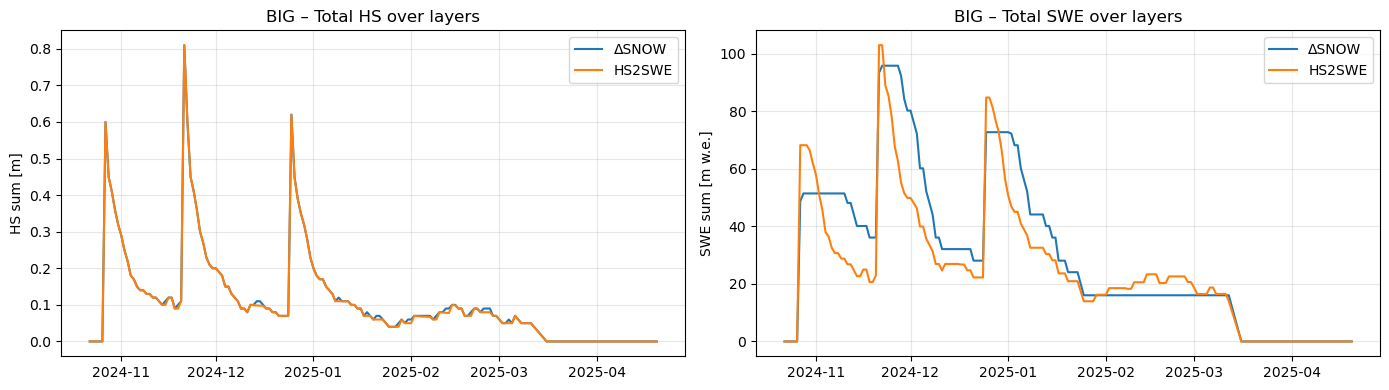



==================== FIRST CHECK: SMALL ====================

HS total over layers:
       ΔSNOW_HS_sum  HS2SWE_HS_sum          diff
count    100.000000     100.000000  1.000000e+02
mean       0.531535       0.531431 -1.040923e-04
std        0.186441       0.186381  4.039717e-04
min        0.000000       0.000000 -1.514560e-03
25%        0.433617       0.433155 -1.787957e-04
50%        0.573422       0.573422 -8.326673e-17
75%        0.664751       0.664641  5.551115e-17
max        0.820959       0.820959  1.179269e-03

SWE total over layers:
       ΔSNOW_SWE_sum  HS2SWE_SWE_sum        diff
count     100.000000      100.000000  100.000000
mean      113.552617      139.185543   25.632926
std        61.476564       67.995079    8.435145
min         0.000000        0.000000    0.000000
25%        72.219447       95.815677   20.991882
50%       117.463233      150.483630   28.258861
75%       160.234022      193.762943   31.166605
max       205.333496      235.689502   35.886668


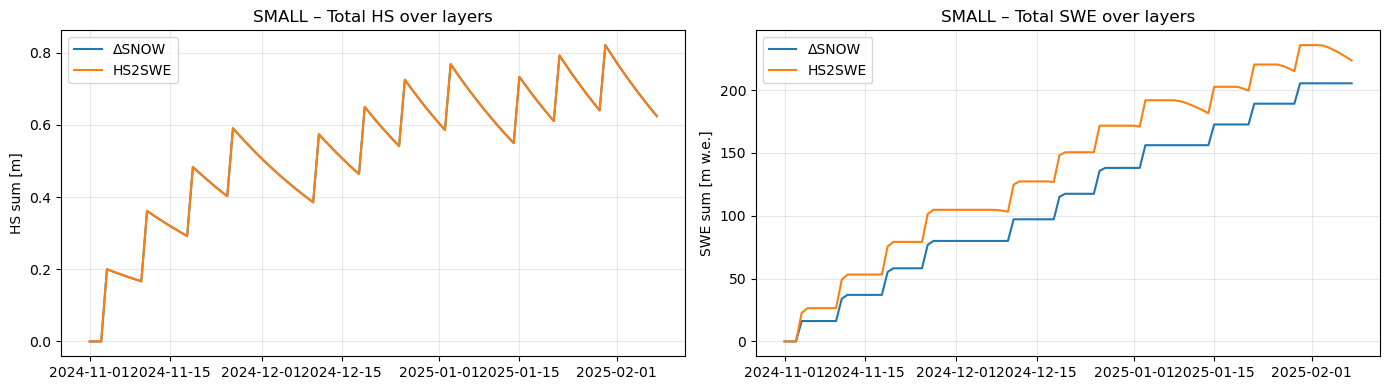

In [7]:
for k in ["big", "small"]:
    print(f"\n\n==================== FIRST CHECK: {k.upper()} ====================")

    ds_dsnow  = cases[k]["ds_dsnow"]
    ds_hs2swe = cases[k]["ds_hs2swe"]
    time_axis = cases[k]["time_axis"]

    hs_sum_ds  = ds_dsnow["HS"].fillna(0).sum(dim="layer")
    hs_sum_hs  = ds_hs2swe["HS"].fillna(0).sum(dim="layer")

    swe_sum_ds = ds_dsnow["SWE_layers"].fillna(0).sum(dim="layer")
    swe_sum_hs = ds_hs2swe["SWE_layers"].fillna(0).sum(dim="layer")

    print("\nHS total over layers:")
    print(pd.DataFrame({
        "ΔSNOW_HS_sum": hs_sum_ds.values,
        "HS2SWE_HS_sum": hs_sum_hs.values,
        "diff": (hs_sum_hs - hs_sum_ds).values
    }).describe())

    print("\nSWE total over layers:")
    print(pd.DataFrame({
        "ΔSNOW_SWE_sum": swe_sum_ds.values,
        "HS2SWE_SWE_sum": swe_sum_hs.values,
        "diff": (swe_sum_hs - swe_sum_ds).values
    }).describe())

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    ax[0].plot(time_axis, hs_sum_ds.values, label="ΔSNOW")
    ax[0].plot(time_axis, hs_sum_hs.values, label="HS2SWE")
    ax[0].set_title(f"{k.upper()} – Total HS over layers")
    ax[0].set_ylabel("HS sum [m]")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(time_axis, swe_sum_ds.values, label="ΔSNOW")
    ax[1].plot(time_axis, swe_sum_hs.values, label="HS2SWE")
    ax[1].set_title(f"{k.upper()} – Total SWE over layers")
    ax[1].set_ylabel("SWE sum [m w.e.]")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

# Stats per case

In [8]:
for k in ["big", "small"]:
    print(f"\n\n==================== CASE: {k.upper()} ====================")
    ds_dsnow  = cases[k]["ds_dsnow"]
    ds_hs2swe = cases[k]["ds_hs2swe"]

    print("\n=== HS stats (time×layer, NaN + zeros removed) ===")
    print(compare_stats(ds_dsnow, ds_hs2swe, "HS"))

    print("\n=== SWE_layers stats (time×layer, NaN + zeros removed) ===")
    print(compare_stats(ds_dsnow, ds_hs2swe, "SWE_layers"))

    print("\n=== RHO stats (time×layer, NaN + zeros removed) ===")
    print(compare_stats(ds_dsnow, ds_hs2swe, "RHO"))

    print("\n=== OVB stats (time×layer, NaN + zeros removed) ===")
    print(compare_stats(ds_dsnow, ds_hs2swe, "OVB"))



==================== CASE: BIG ====================

=== HS stats (time×layer, NaN + zeros removed) ===
          ΔSNOW.HS   HS2SWE.HS
count   589.000000  391.000000
mean      0.033990    0.050628
std       0.073664    0.085990
min       0.000029    0.000159
p25       0.000716    0.009187
median    0.006017    0.018514
p75       0.039935    0.060118
max       0.705709    0.704070

=== SWE_layers stats (time×layer, NaN + zeros removed) ===
        ΔSNOW.SWE_layers  HS2SWE.SWE_layers
count         589.000000         391.000000
mean            9.192057          11.797776
std            14.864922          14.615234
min             0.011515           0.036223
p25             0.287392           2.048012
median          1.931396           2.288353
p75            12.819571          20.653577
max            57.688072          80.052810

=== RHO stats (time×layer, NaN + zeros removed) ===
         ΔSNOW.RHO  HS2SWE.RHO
count   589.000000  391.000000
mean    322.069943  260.251121
std      89.2

## 4) Plot: HS stacked by layer color (2x2 layout)
Top row: ΔSNOW, bottom row: HS2SWE

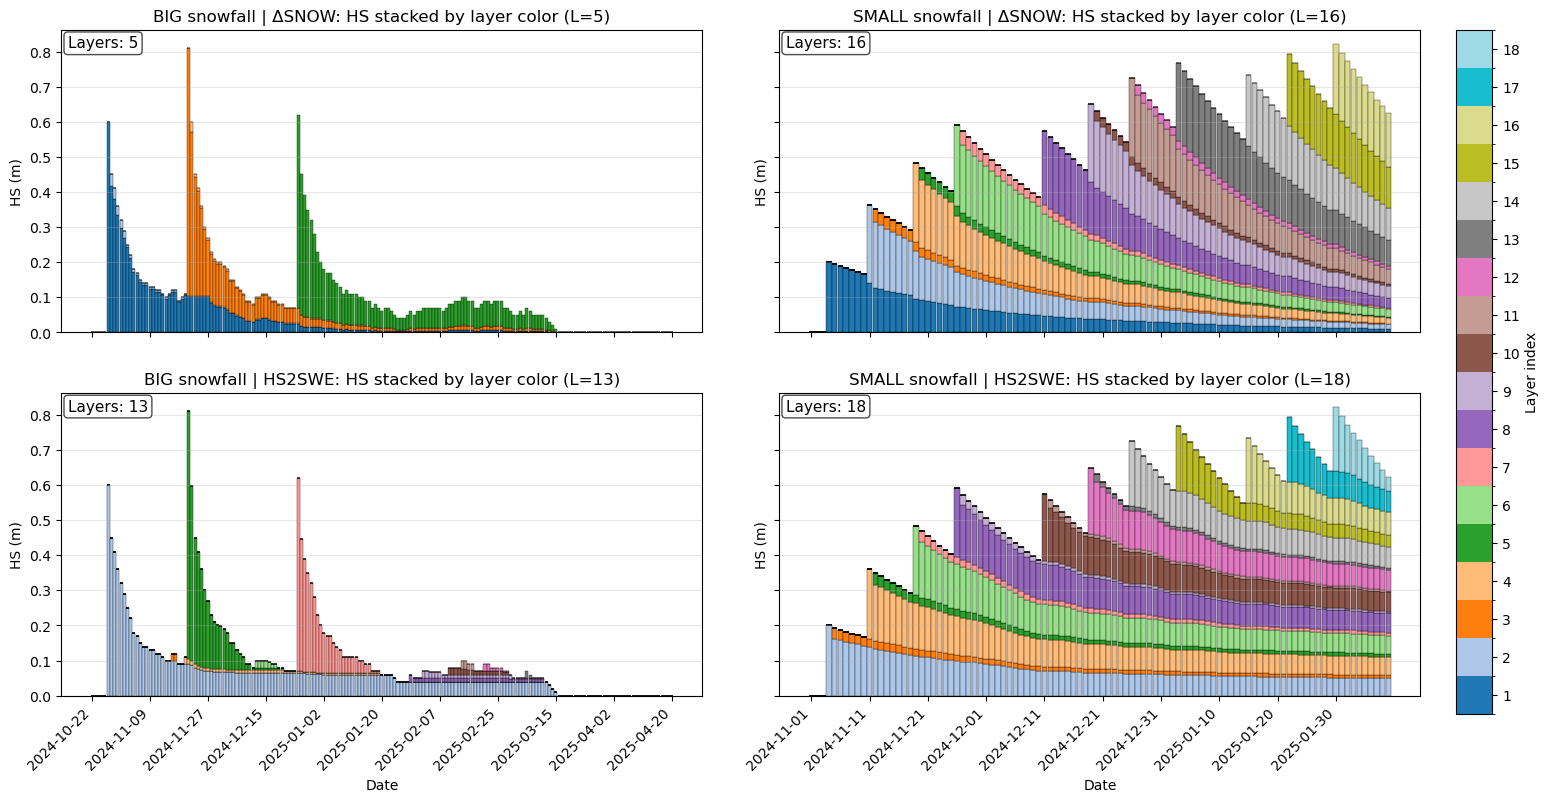

In [9]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

col_titles = {"big": "BIG snowfall", "small": "SMALL snowfall"}

# compute global max layer count directly from loaded arrays
L_max_global = max(
    cases["big"]['ds_dsnow'].HS.shape[1],
    cases["big"]["ds_hs2swe"].HS.shape[1],
    cases["small"]['ds_dsnow'].HS.shape[1],
    cases["small"]["ds_hs2swe"].HS.shape[1],
)

base_cmap = mpl.colormaps["tab20"]
colors = base_cmap(np.linspace(0, 1, L_max_global))
cmap = mpl.colors.ListedColormap(colors)
layer_colors = [colors[i] for i in range(L_max_global)]

fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex="col", sharey="row")

for c, k in enumerate(["big", "small"]):
    time_axis = pd.to_datetime(cases[k]["time_axis"])

    HS_ds = np.asarray(cases[k]["ds_dsnow"].HS, dtype=float)
    HS_hs = np.asarray(cases[k]["ds_hs2swe"].HS, dtype=float)

    T = min(len(time_axis), HS_ds.shape[0], HS_hs.shape[0])
    time_axis = time_axis[:T]

    HS_ds = np.nan_to_num(HS_ds[:T], nan=0.0)
    HS_hs = np.nan_to_num(HS_hs[:T], nan=0.0)

    L_ds_case = HS_ds.shape[1]
    L_hs_case = HS_hs.shape[1]

    axes[0, c].set_title(f"{col_titles[k]} | ΔSNOW: HS stacked by layer color (L={L_ds_case})")
    axes[1, c].set_title(f"{col_titles[k]} | HS2SWE: HS stacked by layer color (L={L_hs_case})")

    for ax, H in [(axes[0, c], HS_ds), (axes[1, c], HS_hs)]:
        x = np.arange(T)
        bottom = np.zeros(T)

        for j in range(H.shape[1]):
            hj = H[:, j]
            if np.allclose(hj, 0.0):
                continue

            ax.bar(
                x,
                hj,
                bottom=bottom,
                color=layer_colors[j],
                edgecolor="black",
                linewidth=0.25,
                width=0.95
            )
            bottom += hj

        ax.set_ylabel("HS (m)")
        ax.grid(True, axis="y", alpha=0.3)

        ax.text(
            0.01, 0.98, f"Layers: {H.shape[1]}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=11,
            bbox=dict(facecolor="white", edgecolor="black", alpha=0.7, boxstyle="round,pad=0.25")
        )

    step = max(1, T // 10)
    ticks = np.arange(0, T, step)

    axes[1, c].set_xticks(ticks)
    axes[1, c].set_xticklabels(
        time_axis[ticks].strftime("%Y-%m-%d"),
        rotation=45,
        ha="right"
    )
    axes[1, c].set_xlabel("Date")

bounds = np.arange(0.5, L_max_global + 1.5, 1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

tick_step = max(1, L_max_global // 10)

fig.subplots_adjust(right=0.88, bottom=0.14, wspace=0.12, hspace=0.20)
cax = fig.add_axes([0.90, 0.12, 0.02, 0.76])
cbar = fig.colorbar(sm, cax=cax, ticks=np.arange(1, L_max_global + 1, tick_step))
cbar.set_label("Layer index")

plt.show()

In [10]:
hs2swe_rho_max = {
    k: float(cases[k]["ds_hs2swe"]["RHO"].max(skipna=True).values)
    for k in ["big", "small"]
}

overall_max_case = max(hs2swe_rho_max, key=hs2swe_rho_max.get)
overall_max_value = hs2swe_rho_max[overall_max_case]

print("HS2SWE max density by case:", hs2swe_rho_max)
print(f"Overall max HS2SWE density: {overall_max_value:.4f} (case: {overall_max_case})")

HS2SWE max density by case: {'big': 352.4581208181807, 'small': 454.13776990365807}
Overall max HS2SWE density: 454.1378 (case: small)


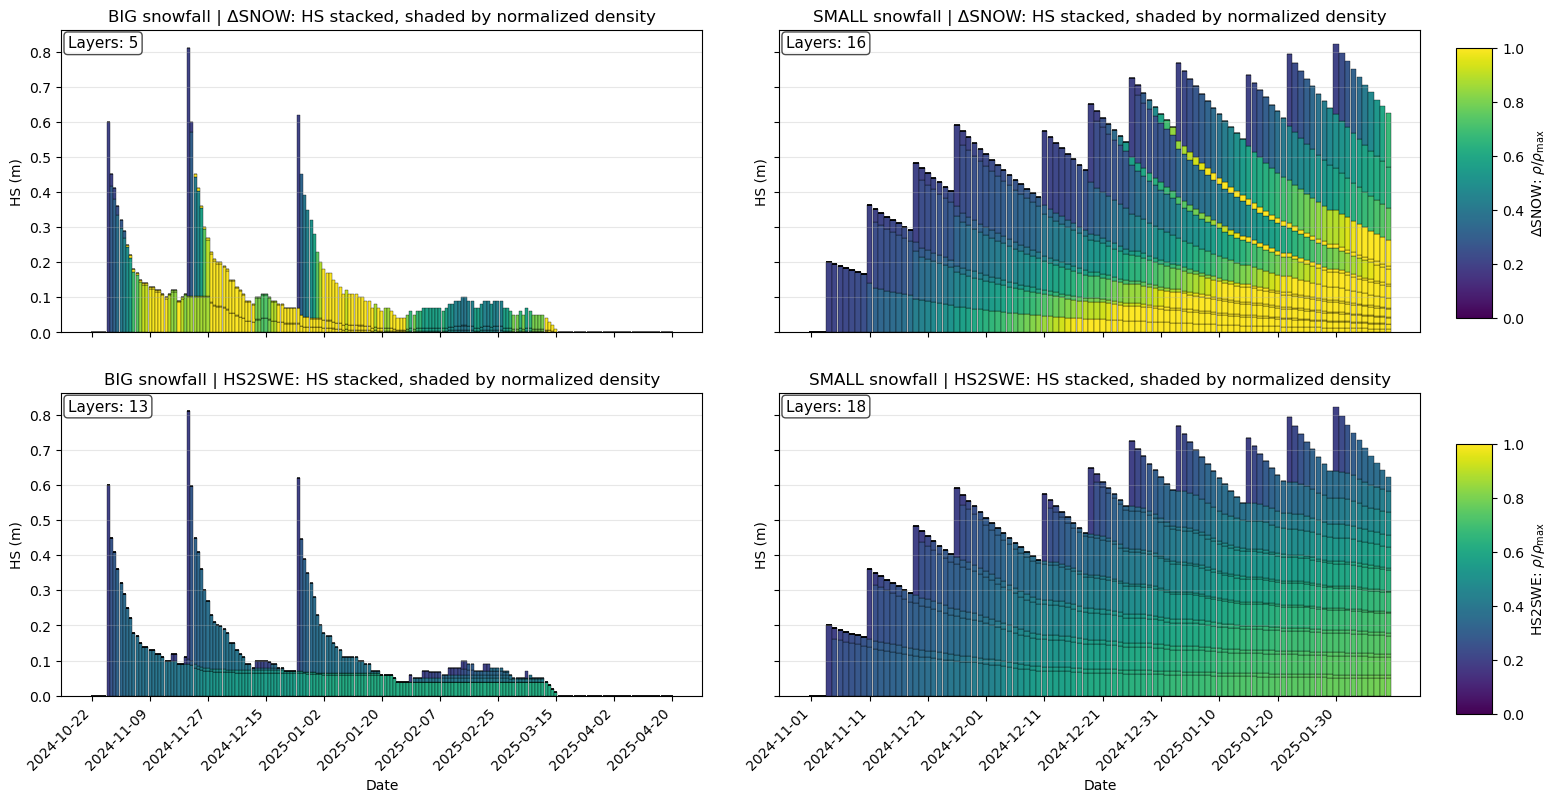

In [11]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

col_titles = {"big": "BIG snowfall", "small": "SMALL snowfall"}

# Model-specific rho maxima
rho_max_dsnow = 401.0
rho_max_hs2swe = 571.6

# Better colormap
rho_cmap = mpl.colormaps["viridis"]

fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex="col", sharey="row")

for c, k in enumerate(["big", "small"]):
    time_axis = pd.to_datetime(cases[k]["time_axis"])

    HS_ds  = np.asarray(cases[k]["ds_dsnow"].HS, dtype=float)
    HS_hs  = np.asarray(cases[k]["ds_hs2swe"].HS, dtype=float)
    RHO_ds = np.asarray(cases[k]["ds_dsnow"].RHO, dtype=float)
    RHO_hs = np.asarray(cases[k]["ds_hs2swe"].RHO, dtype=float)

    T = min(len(time_axis), HS_ds.shape[0], HS_hs.shape[0], RHO_ds.shape[0], RHO_hs.shape[0])
    time_axis = time_axis[:T]

    HS_ds  = np.nan_to_num(HS_ds[:T], nan=0.0)
    HS_hs  = np.nan_to_num(HS_hs[:T], nan=0.0)
    RHO_ds = np.nan_to_num(RHO_ds[:T], nan=0.0)
    RHO_hs = np.nan_to_num(RHO_hs[:T], nan=0.0)

    axes[0, c].set_title(f"{col_titles[k]} | ΔSNOW: HS stacked, shaded by normalized density")
    axes[1, c].set_title(f"{col_titles[k]} | HS2SWE: HS stacked, shaded by normalized density")

    # ----------------------------
    # Top row: ΔSNOW
    # ----------------------------
    ax = axes[0, c]
    x = np.arange(T)
    bottom = np.zeros(T)

    for j in range(HS_ds.shape[1]):
        hj = HS_ds[:, j]
        rj = RHO_ds[:, j]

        if np.allclose(hj, 0.0):
            continue

        rho_norm = np.clip(rj / rho_max_dsnow, 0.0, 1.0)
        bar_colors = rho_cmap(rho_norm)

        ax.bar(
            x,
            hj,
            bottom=bottom,
            color=bar_colors,
            edgecolor="black",
            linewidth=0.25,
            width=0.95
        )
        bottom += hj

    ax.set_ylabel("HS (m)")
    ax.grid(True, axis="y", alpha=0.3)
    ax.text(
        0.01, 0.98,
        f"Layers: {HS_ds.shape[1]}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.7, boxstyle="round,pad=0.25")
    )

    # ----------------------------
    # Bottom row: HS2SWE
    # ----------------------------
    ax = axes[1, c]
    bottom = np.zeros(T)

    for j in range(HS_hs.shape[1]):
        hj = HS_hs[:, j]
        rj = RHO_hs[:, j]

        if np.allclose(hj, 0.0):
            continue

        rho_norm = np.clip(rj / rho_max_hs2swe, 0.0, 1.0)
        bar_colors = rho_cmap(rho_norm)

        ax.bar(
            x,
            hj,
            bottom=bottom,
            color=bar_colors,
            edgecolor="black",
            linewidth=0.25,
            width=0.95
        )
        bottom += hj

    ax.set_ylabel("HS (m)")
    ax.grid(True, axis="y", alpha=0.3)
    ax.text(
        0.01, 0.98,
        f"Layers: {HS_hs.shape[1]}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.7, boxstyle="round,pad=0.25")
    )

    # ----------------------------
    # X-axis formatting
    # ----------------------------
    step = max(1, T // 10)
    ticks = np.arange(0, T, step)

    axes[1, c].set_xticks(ticks)
    axes[1, c].set_xticklabels(
        time_axis[ticks].strftime("%Y-%m-%d"),
        rotation=45,
        ha="right"
    )
    axes[1, c].set_xlabel("Date")

# ----------------------------
# Two colorbars, both 0-1
# ----------------------------
norm_rel = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap=rho_cmap, norm=norm_rel)
sm.set_array([])

fig.subplots_adjust(right=0.88, bottom=0.14, wspace=0.12, hspace=0.20)

# top-row colorbar
cax1 = fig.add_axes([0.90, 0.56, 0.02, 0.30])
cbar1 = fig.colorbar(sm, cax=cax1)
cbar1.set_label(r"ΔSNOW: $\rho / \rho_{\max}$")
cbar1.set_ticks(np.linspace(0, 1, 6))

# bottom-row colorbar
cax2 = fig.add_axes([0.90, 0.12, 0.02, 0.30])
cbar2 = fig.colorbar(sm, cax=cax2)
cbar2.set_label(r"HS2SWE: $\rho / \rho_{\max}$")
cbar2.set_ticks(np.linspace(0, 1, 6))

plt.show()

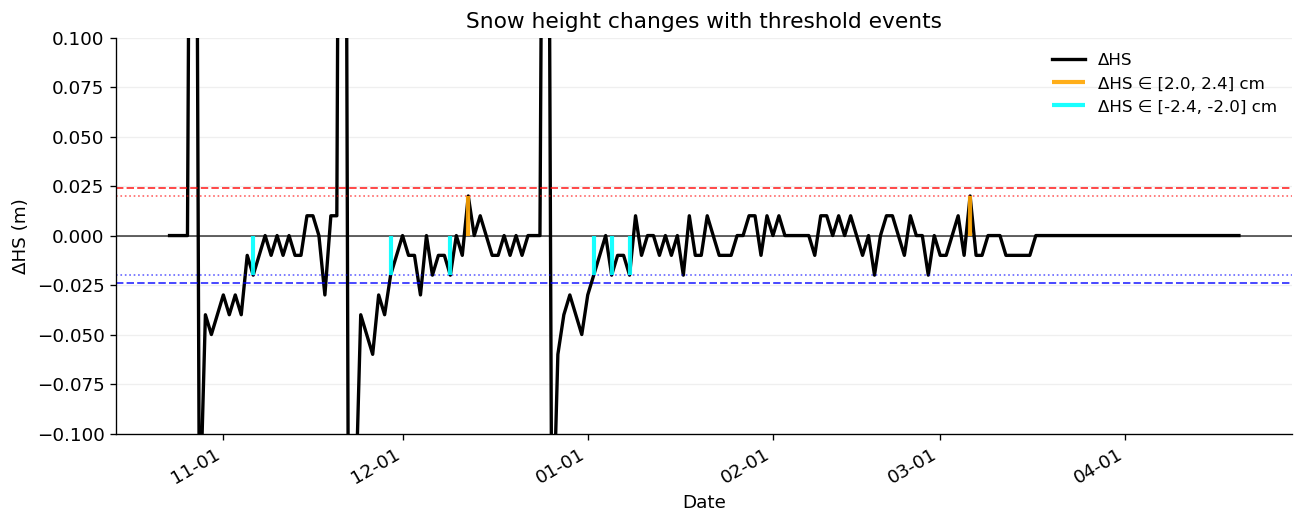

In [12]:
# ----------------------------
# Style
# ----------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ----------------------------
# Load data
# ----------------------------
snow_heigth = pd.read_csv(
    '/Users/jakobwerkgarner/code/mt_dsnow/model_diff/moduls/Dry_settling/synthetic_snowfalls/synthetic_big_snowfalls_100days.csv'
)

# Ensure datetime
snow_heigth["timestamp"] = pd.to_datetime(snow_heigth["timestamp"])

# Compute difference
snow_heigth['dHS'] = snow_heigth['HS_meas'].diff()

x = snow_heigth["timestamp"]
y = snow_heigth['dHS'].to_numpy()

# Thresholds
thr_24 = 0.024
thr_20 = 0.020

# Masks
mask_pos = (y > thr_20) & (y <= thr_24)
mask_neg = (y < -thr_20) & (y >= -thr_24)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(11, 4.5))

# Main line
ax.plot(
    x, y,
    linewidth=2,
    color="black",
    label="ΔHS"
)

# Reference lines
ax.axhline(0.0, linewidth=1.2, color="black", alpha=0.6)

ax.axhline(thr_24, linewidth=1.2, linestyle='--', color="red", alpha=0.7)
ax.axhline(-thr_24, linewidth=1.2, linestyle='--', color="blue", alpha=0.7)

ax.axhline(thr_20, linewidth=1.0, linestyle=':', color="red", alpha=0.6)
ax.axhline(-thr_20, linewidth=1.0, linestyle=':', color="blue", alpha=0.6)

# ----------------------------
# Vertical bars (clean colors)
# ----------------------------
ax.vlines(
    x[mask_pos],
    ymin=0,
    ymax=y[mask_pos],
    linewidth=2.5,
    color="orange",
    alpha=0.9,
    label="ΔHS ∈ [2.0, 2.4] cm"
)

ax.vlines(
    x[mask_neg],
    ymin=0,
    ymax=y[mask_neg],
    linewidth=2.5,
    color="cyan",
    alpha=0.9,
    label="ΔHS ∈ [-2.4, -2.0] cm"
)

# ----------------------------
# Time axis formatting (IMPORTANT)
# ----------------------------
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

fig.autofmt_xdate(rotation=30)

# ----------------------------
# Labels
# ----------------------------
ax.set_title("Snow height changes with threshold events")
ax.set_xlabel("Date")
ax.set_ylabel("ΔHS (m)")
ax.grid(axis="y", alpha=0.2)
ax.set_ylim(-0.1, 0.1)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

# Plot Cumalative HSN

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the ordering is correct
plot_df = first_nonzero_hs.copy()
plot_df = plot_df.sort_values(["case", "model", "first_nonzero_time_idx", "layer"])

# Replace NaN values by 0 for the cumulative sum
plot_df["new_snow_height_first_nonzero"] = plot_df["new_snow_height_first_nonzero"].fillna(0.0)

# Compute cumulative sum within each case and model
plot_df["HSN_cumsum"] = (
    plot_df.groupby(["case", "model"])["new_snow_height_first_nonzero"]
    .cumsum()
)

# Plot: big and small side by side, both models in each subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, case in zip(axes, ["big", "small"]):
    sub = plot_df[plot_df["case"] == case]

    for model in ["ΔSNOW", "HS2SWE"]:
        s = sub[sub["model"] == model].sort_values("first_nonzero_time_idx")

        ax.plot(
            s["first_nonzero_time_idx"],
            s["HSN_cumsum"],
            marker="o",
            label=model
        )

    ax.set_title(f"{case.capitalize()} case")
    ax.set_xlabel("Time index through season")
    ax.set_ylabel("Cumulative HSN")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("Cumulative new snow height through the season", fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'first_nonzero_hs' is not defined

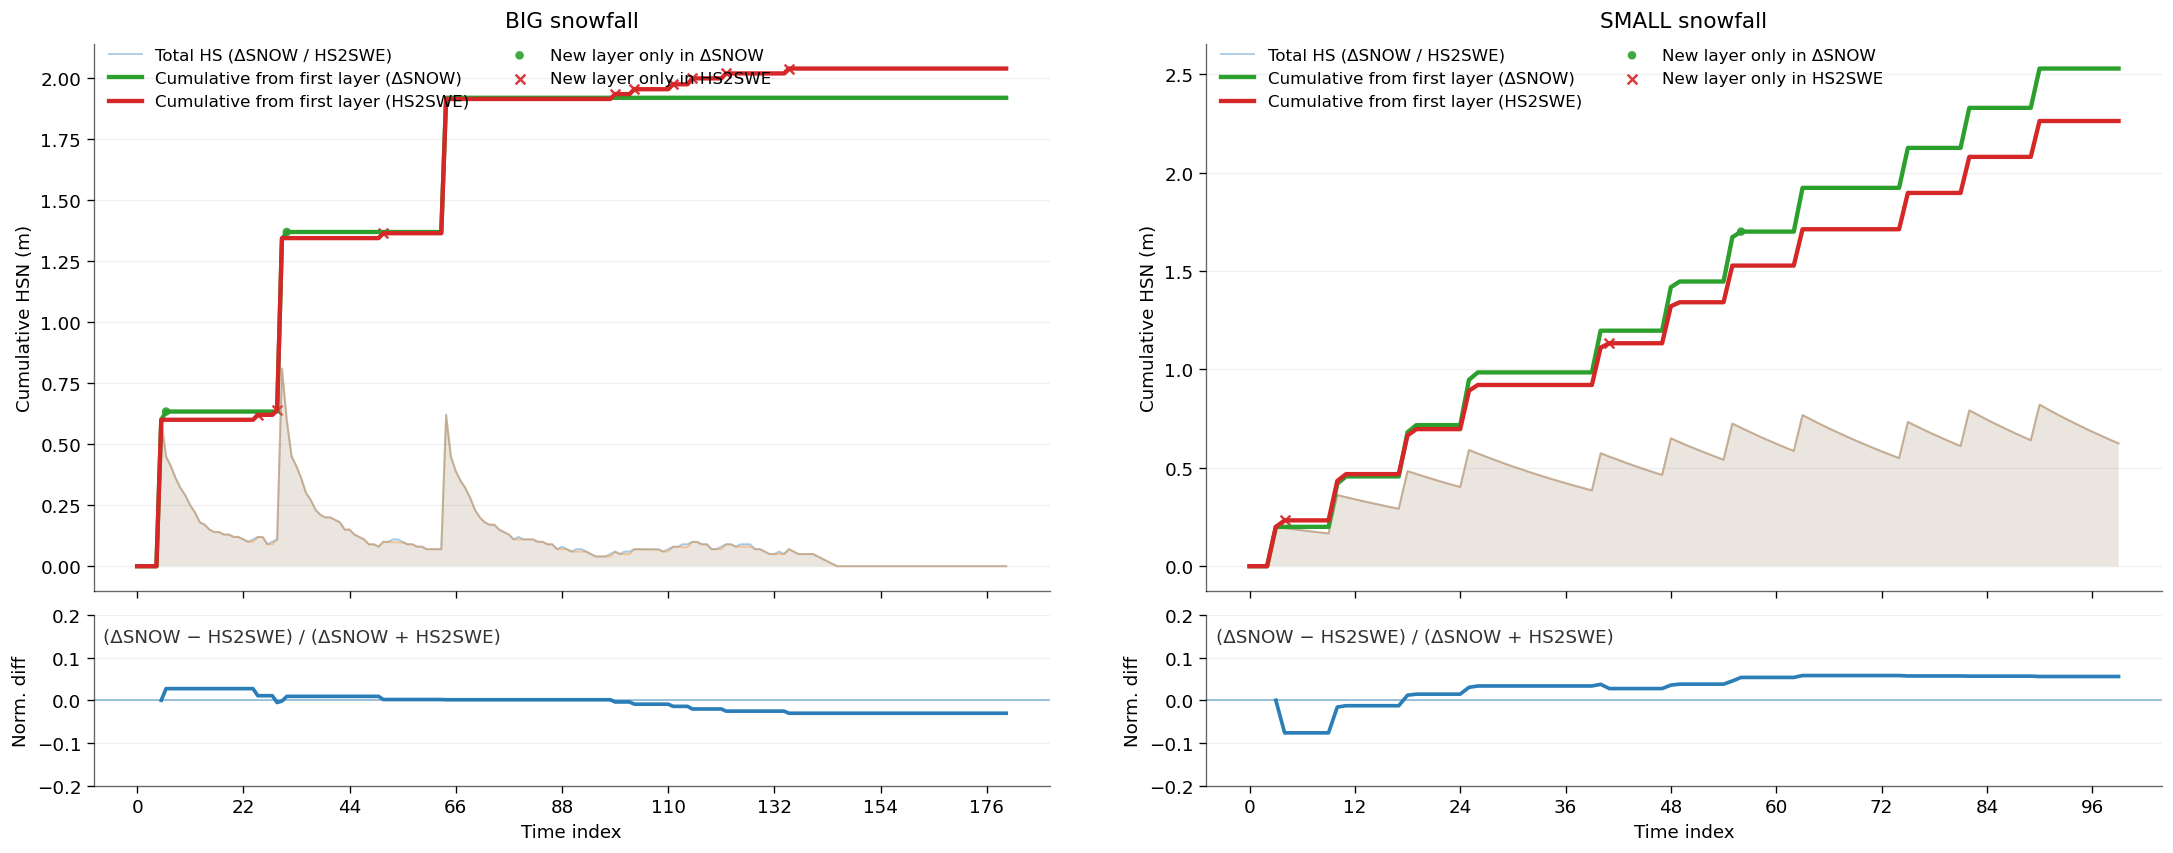

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------
# Global "modern" style
# ----------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

def _beautify_axes(ax):
    ax.set_facecolor("white")
    ax.spines["left"].set_alpha(0.6)
    ax.spines["bottom"].set_alpha(0.6)
    ax.tick_params(axis="both", which="major", length=4, width=0.8)
    ax.grid(axis="y", alpha=0.18, linewidth=0.8)

def _nice_xticks(ax, x, max_ticks=8):
    n = len(x)
    if n <= max_ticks:
        return
    step = max(1, n // max_ticks)
    ticks = np.arange(0, n, step)
    ax.set_xticks(np.asarray(x)[ticks])

def cumulative_from_first_nonzero(H):
    """
    H: array of shape (time, layer)

    Returns
    -------
    df : DataFrame with columns:
         - increment
         - cumulative
    event_times : positions where a new layer first appears
    event_y     : cumulative values at these positions
    """
    H = np.asarray(H, dtype=float)
    H = np.nan_to_num(H, nan=0.0)

    n_time, n_layer = H.shape

    first_idx = np.argmax(H > 0, axis=0)
    has_nonzero = np.any(H > 0, axis=0)

    first_vals = np.where(has_nonzero, H[first_idx, np.arange(n_layer)], np.nan)

    inc = np.zeros(n_time, dtype=float)
    valid = has_nonzero & np.isfinite(first_vals)

    np.add.at(inc, first_idx[valid], first_vals[valid])

    df = pd.DataFrame({
        "increment": inc,
        "cumulative": np.cumsum(inc)
    }, index=np.arange(n_time))

    event_times = np.where(inc > 0)[0]
    event_y = df.loc[event_times, "cumulative"].to_numpy()

    return df, event_times, event_y

def plot_case(ax_main, ax_nd, case_key, eps=1e-12):
    _beautify_axes(ax_main)
    _beautify_axes(ax_nd)

    H_dsnow  = cases[case_key]["ds_dsnow"]["HS"]
    H_hs2swe = cases[case_key]["ds_hs2swe"]["HS"]

    # Total HS over all layers as soft background
    hs_total_dsnow  = np.nansum(np.asarray(H_dsnow, dtype=float), axis=1)
    hs_total_hs2swe = np.nansum(np.asarray(H_hs2swe, dtype=float), axis=1)

    x1 = np.arange(len(hs_total_dsnow))
    x2 = np.arange(len(hs_total_hs2swe))
    x_common = np.arange(max(len(hs_total_dsnow), len(hs_total_hs2swe)))

    hs_total_dsnow_i = np.interp(x_common, x1, hs_total_dsnow)
    hs_total_hs2swe_i = np.interp(x_common, x2, hs_total_hs2swe)

    ax_main.fill_between(x_common, 0.0, hs_total_dsnow_i, alpha=0.10, linewidth=0)
    ax_main.fill_between(x_common, 0.0, hs_total_hs2swe_i, alpha=0.10, linewidth=0)

    ax_main.plot(x_common, hs_total_dsnow_i, linewidth=1.2, alpha=0.35, label="Total HS (ΔSNOW / HS2SWE)")
    ax_main.plot(x_common, hs_total_hs2swe_i, linewidth=1.2, alpha=0.35)

    # Cumulative first-appearance HS
    df_dsnow, event_t_dsnow, event_y_dsnow = cumulative_from_first_nonzero(H_dsnow)
    df_hs2swe, event_t_hs2swe, event_y_hs2swe = cumulative_from_first_nonzero(H_hs2swe)

    x_common2 = np.arange(max(len(df_dsnow), len(df_hs2swe)))

    c1 = np.interp(x_common2, np.arange(len(df_dsnow)), df_dsnow["cumulative"].to_numpy())
    c2 = np.interp(x_common2, np.arange(len(df_hs2swe)), df_hs2swe["cumulative"].to_numpy())

    denom = c1 + c2
    nd = (c1 - c2) / np.where(np.abs(denom) < eps, np.nan, denom)

    # XOR event times
    ds_set = pd.Index(event_t_dsnow)
    hs_set = pd.Index(event_t_hs2swe)

    ds_only = ds_set.difference(hs_set).to_numpy()
    hs_only = hs_set.difference(ds_set).to_numpy()

    ds_only_y = df_dsnow.loc[ds_only, "cumulative"].to_numpy() if len(ds_only) > 0 else np.array([])
    hs_only_y = df_hs2swe.loc[hs_only, "cumulative"].to_numpy() if len(hs_only) > 0 else np.array([])

    # Main panel
    ax_main.plot(
        df_dsnow.index,
        df_dsnow["cumulative"],
        linewidth=2.6,
        label="Cumulative from first layer (ΔSNOW)"
    )
    ax_main.plot(
        df_hs2swe.index,
        df_hs2swe["cumulative"],
        linewidth=2.6,
        label="Cumulative from first layer (HS2SWE)"
    )

    ax_main.scatter(
        ds_only, ds_only_y,
        s=26, marker="o", edgecolors="none", alpha=0.9,
        label="New layer only in ΔSNOW"
    )
    ax_main.scatter(
        hs_only, hs_only_y,
        s=34, marker="x", alpha=0.9,
        label="New layer only in HS2SWE"
    )

    ax_main.set_title(f"{case_key.upper()} snowfall", pad=10)
    ax_main.set_ylabel("Cumulative HSN (m)")
    ax_main.margins(x=0.01)
    ax_main.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.0, 1.02), ncols=2)

    _nice_xticks(ax_main, x_common2, max_ticks=8)

    # Normalized difference panel
    ax_nd.plot(x_common2, nd, linewidth=2.2, alpha=0.95)
    ax_nd.axhline(0.0, linewidth=1.0, alpha=0.5)

    nd_abs = np.nanmax(np.abs(nd)) if np.isfinite(nd).any() else 1.0
    nd_lim = max(0.2, min(1.0, 1.05 * nd_abs))
    ax_nd.set_ylim(-nd_lim, nd_lim)

    ax_nd.set_ylabel("Norm. diff")
    ax_nd.set_xlabel("Time index")

    ax_nd.text(
        0.01, 0.92,
        "(ΔSNOW − HS2SWE) / (ΔSNOW + HS2SWE)",
        transform=ax_nd.transAxes,
        ha="left", va="top",
        alpha=0.8
    )

    _nice_xticks(ax_nd, x_common2, max_ticks=8)

# ============================================================
# Two subfigures: BIG (left) and SMALL (right)
# each with 2 rows: main + normalized diff
# ============================================================
fig = plt.figure(figsize=(18, 7), constrained_layout=True)
subfigs = fig.subfigures(1, 2, wspace=0.06)

for sf, key in zip(subfigs, ["big", "small"]):
    axs = sf.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": [3.2, 1]})
    ax_main, ax_nd = axs
    plot_case(ax_main=ax_main, ax_nd=ax_nd, case_key=key)

plt.show()

In [15]:
ds_dsnow = cases['big']["ds_dsnow"]

In [ ]:
MR['DIA'][3, t]

NameError: name 'MR' is not defined